# EDA — PAD-UFES-20
**Tesis:** Integración multimodal eficiente de modelos de visión y lenguaje para detección de cáncer de piel  
**Autora:** Noemi Alejandra Huarino  

Este notebook cubre:
1. Montaje de Drive y carga de datos
2. Análisis estadístico del metadata
3. Verificación de imágenes (3 subcarpetas)
4. Distribución de clases
5. Análisis de variables clínicas
6. Visualización de imágenes por clase
7. Detección de posibles problemas

## 0. Montar Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Configuración de rutas

In [2]:
import os

BASE_PATH  = '/content/drive/MyDrive/PFC1 - Noemi/dataset/PAD-UFES-20'
CSV_PATH   = os.path.join(BASE_PATH, 'metadata_imputed.csv')
IMGS_DIR   = os.path.join(BASE_PATH, 'images')

# Las 3 subcarpetas de imágenes
IMG_PARTS  = [
    os.path.join(IMGS_DIR, 'imgs_part_1'),
    os.path.join(IMGS_DIR, 'imgs_part_2'),
    os.path.join(IMGS_DIR, 'imgs_part_3'),
]

# Verificar que existen
print(f'CSV existe: {os.path.exists(CSV_PATH)}')
for p in IMG_PARTS:
    n = len(os.listdir(p)) if os.path.exists(p) else 'NO ENCONTRADA'
    print(f'{os.path.basename(p)}: {n} archivos')

CSV existe: True
imgs_part_1: 911 archivos
imgs_part_2: 659 archivos
imgs_part_3: 728 archivos


## 2. Cargar metadata

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv(CSV_PATH)
print(f'Shape: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')
df.head()

Shape: (2298, 26)
Columnas: ['patient_id', 'lesion_id', 'smoke', 'drink', 'background_father', 'background_mother', 'age', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'fitspatrick', 'region', 'diameter_1', 'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'img_id', 'biopsed']


,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,False,False,POMERANIA,POMERANIA,8,False,FEMALE,False,...,5.0,NEV,False,False,False,False,False,False,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,True,True,False,True,True,True,PAT_46_881_939.png,True
2,PAT_1545,1867,False,False,POMERANIA,POMERANIA,77,False,FEMALE,False,...,7.0,ACK,True,False,False,False,False,False,PAT_1545_1867_547.png,False
3,PAT_1989,4061,False,False,POMERANIA,POMERANIA,75,False,FEMALE,False,...,7.0,ACK,True,False,False,False,False,False,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,5.0,BCC,True,True,False,False,True,True,PAT_684_1302_588.png,True


In [5]:
# Verificar que no hay nulos (post-imputación)
nulls = df.isnull().sum()
print('Nulos por columna:')
print(nulls[nulls > 0] if nulls.any() else ' Sin valores nulos')

print('\nTipos de datos:')
print(df.dtypes)

Nulos por columna:
 Sin valores nulos

Tipos de datos:
patient_id              object
lesion_id                int64
smoke                     bool
drink                     bool
background_father       object
background_mother       object
age                      int64
pesticide                 bool
gender                  object
skin_cancer_history       bool
cancer_history            bool
has_piped_water           bool
has_sewage_system         bool
fitspatrick            float64
region                  object
diameter_1             float64
diameter_2             float64
diagnostic              object
itch                    object
grew                    object
hurt                    object
changed                 object
bleed                   object
elevation               object
img_id                  object
biopsed                   bool
dtype: object


## 3. Distribución de clases

In [6]:
import matplotlib.pyplot as plt

# Distribución multiclase
class_counts = df['diagnostic'].value_counts()
print('Distribución multiclase:')
print(class_counts)

# Binarización (según tesis)
MALIGNANT = {'BCC', 'MEL', 'SCC'}
df['label'] = df['diagnostic'].apply(lambda x: 1 if x in MALIGNANT else 0)
binary_counts = df['label'].value_counts()
print(f'\nBinario — Maligno (1): {binary_counts[1]} | Benigno (0): {binary_counts[0]}')
print(f'Ratio desbalance: {binary_counts[0]/binary_counts[1]:.2f}:1')

Distribución multiclase:
diagnostic
BCC    845
ACK    730
NEV    244
SEK    235
SCC    192
MEL     52
Name: count, dtype: int64

Binario — Maligno (1): 1089 | Benigno (0): 1209
Ratio desbalance: 1.11:1


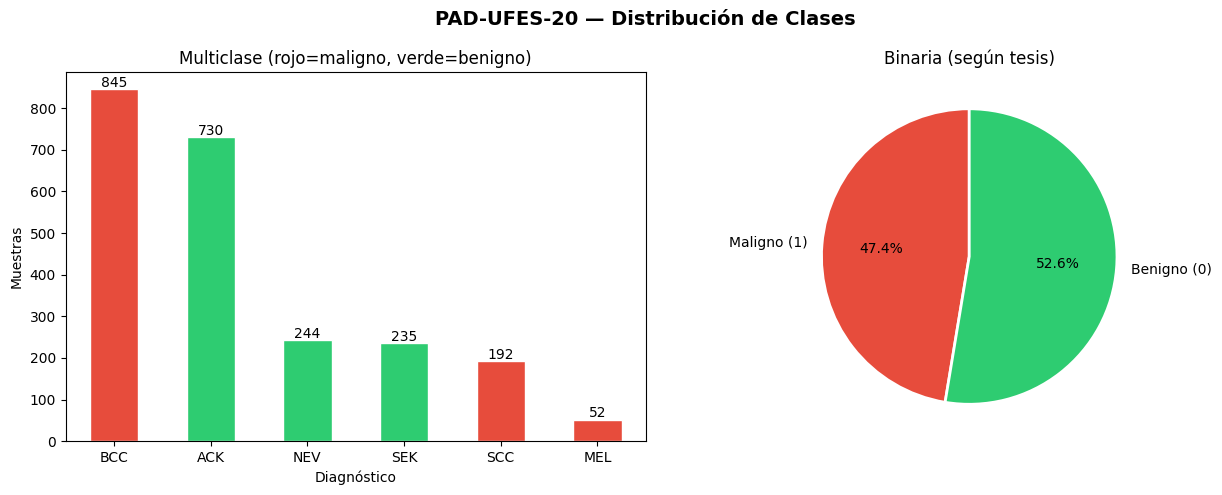

Guardado: eda_distribucion_clases.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('PAD-UFES-20 — Distribución de Clases', fontsize=14, fontweight='bold')

# Multiclase
colors = ['#e74c3c' if c in MALIGNANT else '#2ecc71' for c in class_counts.index]
class_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Multiclase (rojo=maligno, verde=benigno)')
axes[0].set_xlabel('Diagnóstico')
axes[0].set_ylabel('Muestras')
axes[0].tick_params(axis='x', rotation=0)
for bar, val in zip(axes[0].patches, class_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontsize=10)

# Binaria
axes[1].pie([binary_counts[1], binary_counts[0]],
            labels=['Maligno (1)', 'Benigno (0)'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Binaria (según tesis)')

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'eda_distribucion_clases.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: eda_distribucion_clases.png')

## 4. Análisis de variables clínicas

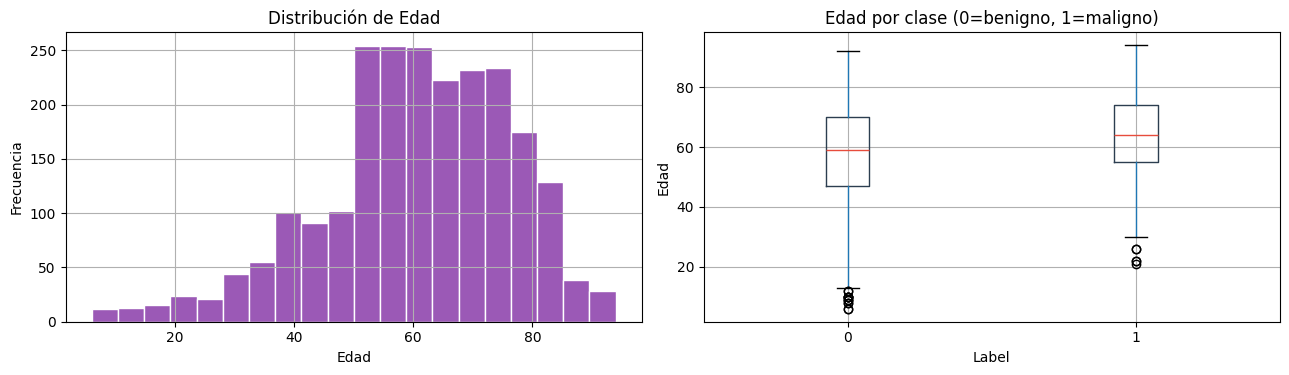

        count       mean        std   min   25%   50%   75%   max
label                                                            
0      1209.0  57.283706  17.197472   6.0  47.0  59.0  70.0  92.0
1      1089.0  63.996327  13.464413  21.0  55.0  64.0  74.0  94.0


In [9]:
# Distribución de edad
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['age'].hist(bins=20, ax=axes[0], color='#9b59b6', edgecolor='white')
axes[0].set_title('Distribución de Edad')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

# Edad por clase binaria
df.boxplot(column='age', by='label', ax=axes[1],
           boxprops=dict(color='#2c3e50'),
           medianprops=dict(color='#e74c3c'))
axes[1].set_title('Edad por clase (0=benigno, 1=maligno)')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Edad')
plt.suptitle('')

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'eda_edad.png'), dpi=150, bbox_inches='tight')
plt.show()
print(df.groupby('label')['age'].describe())

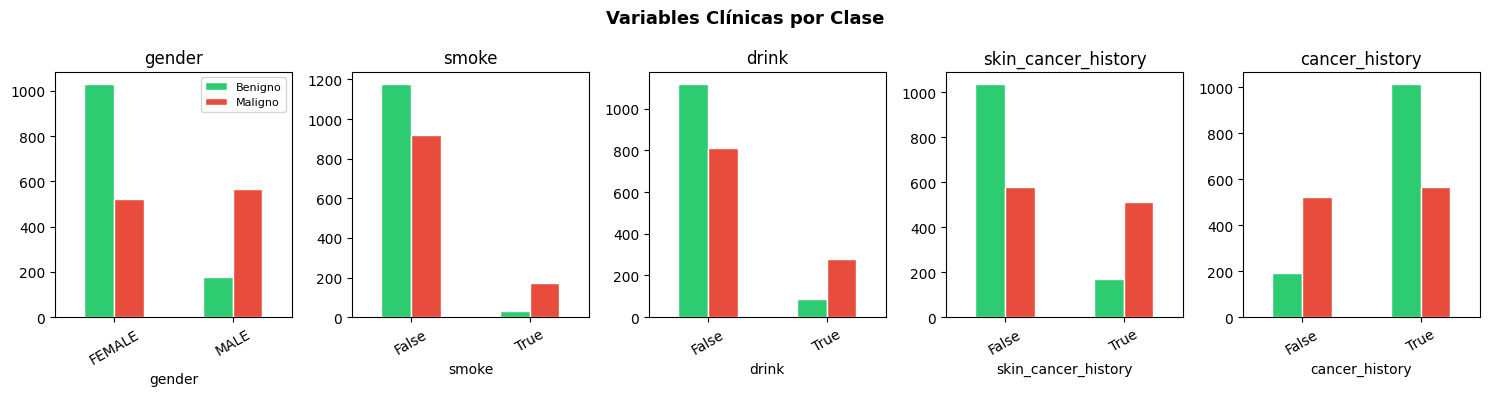

In [10]:
# Variables categóricas clave
cat_cols = ['gender', 'smoke', 'drink', 'skin_cancer_history', 'cancer_history']
cat_cols = [c for c in cat_cols if c in df.columns]

fig, axes = plt.subplots(1, len(cat_cols), figsize=(15, 4))
for i, col in enumerate(cat_cols):
    vc = df.groupby([col, 'label']).size().unstack(fill_value=0)
    vc.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
            edgecolor='white', legend=(i == 0))
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)
    if i == 0:
        axes[i].legend(['Benigno', 'Maligno'], fontsize=8)

plt.suptitle('Variables Clínicas por Clase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'eda_variables_clinicas.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Verificación de imágenes

In [11]:
# Construir índice de todas las imágenes en las 3 subcarpetas
img_index = {}
for part in IMG_PARTS:
    for fname in os.listdir(part):
        img_index[fname] = os.path.join(part, fname)

print(f'Total imágenes encontradas en disco: {len(img_index)}')
print(f'Total filas en metadata: {len(df)}')

# Verificar cuántas del CSV tienen imagen
df['img_path'] = df['img_id'].apply(lambda x: img_index.get(str(x), None))
encontradas = df['img_path'].notna().sum()
faltantes   = df['img_path'].isna().sum()

print(f'\nImágenes encontradas en CSV: {encontradas}')
print(f'Imágenes faltantes:          {faltantes}')

if faltantes > 0:
    print('\nEjemplos de img_id no encontrados:')
    print(df[df['img_path'].isna()]['img_id'].head(10).tolist())

Total imágenes encontradas en disco: 2298
Total filas en metadata: 2298

Imágenes encontradas en CSV: 2298
Imágenes faltantes:          0


In [12]:
# Verificar imágenes corruptas (intentar abrirlas)
from PIL import Image
from tqdm.notebook import tqdm

corruptas = []
sample = df[df['img_path'].notna()].sample(min(200, encontradas), random_state=42)

for _, row in tqdm(sample.iterrows(), total=len(sample), desc='Verificando imágenes'):
    try:
        img = Image.open(row['img_path'])
        img.verify()
    except Exception as e:
        corruptas.append((row['img_id'], str(e)))

print(f'Imágenes corruptas en muestra de {len(sample)}: {len(corruptas)}')
if corruptas:
    print(corruptas[:5])

Verificando imágenes:   0%|          | 0/200 [00:00<?, ?it/s]

Imágenes corruptas en muestra de 200: 0


In [13]:
# Dimensiones de imágenes (muestra de 100)
dims = []
sample2 = df[df['img_path'].notna()].sample(min(100, encontradas), random_state=0)
for _, row in sample2.iterrows():
    try:
        img = Image.open(row['img_path'])
        dims.append(img.size)  # (width, height)
    except:
        pass

widths  = [d[0] for d in dims]
heights = [d[1] for d in dims]
print(f'Ancho  — min: {min(widths)}, max: {max(widths)}, promedio: {np.mean(widths):.0f}px')
print(f'Alto   — min: {min(heights)}, max: {max(heights)}, promedio: {np.mean(heights):.0f}px')
print('\n(El preprocesamiento las redimensionará a 224x224 como indica la tesis)')

Ancho  — min: 235, max: 2683, promedio: 942px
Alto   — min: 235, max: 2683, promedio: 942px

(El preprocesamiento las redimensionará a 224x224 como indica la tesis)


## 6. Visualización de imágenes por clase

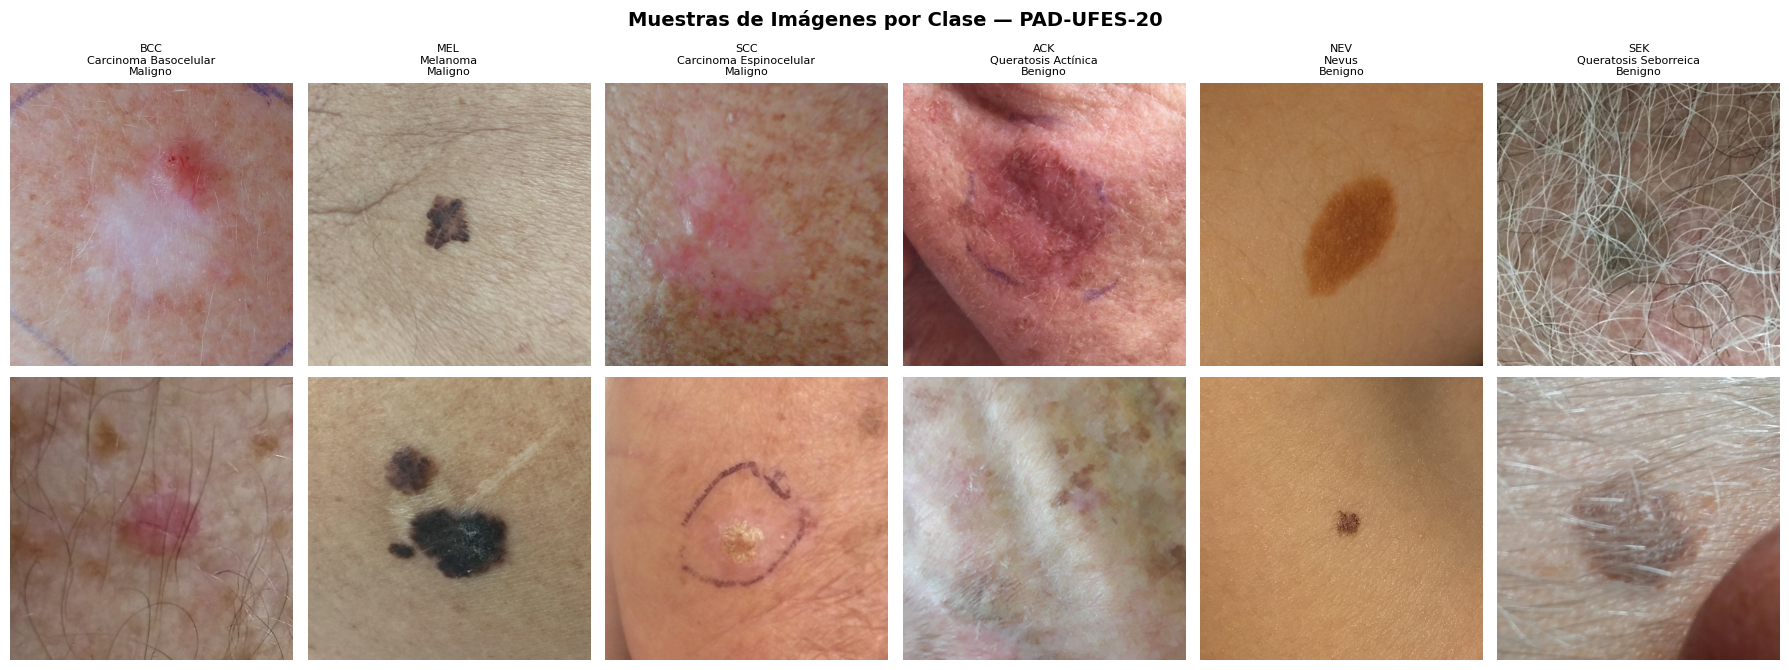

✅ Guardado: eda_muestras_imagenes.png


In [14]:
classes   = ['BCC', 'MEL', 'SCC', 'ACK', 'NEV', 'SEK']
desc_map  = {'BCC': 'Carcinoma Basocelular', 'MEL': 'Melanoma',
             'SCC': 'Carcinoma Espinocelular', 'ACK': 'Queratosis Actínica',
             'NEV': 'Nevus', 'SEK': 'Queratosis Seborreica'}

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
fig.suptitle('Muestras de Imágenes por Clase — PAD-UFES-20', fontsize=14, fontweight='bold')

for col_i, cls in enumerate(classes):
    subset = df[(df['diagnostic'] == cls) & (df['img_path'].notna())]
    tipo   = 'Maligno' if cls in MALIGNANT else 'Benigno'
    for row_i in range(2):
        ax = axes[row_i][col_i]
        ax.axis('off')
        if row_i < len(subset):
            try:
                img = Image.open(subset.iloc[row_i]['img_path'])
                ax.imshow(img)
                if row_i == 0:
                    ax.set_title(f'{cls}\n{desc_map[cls]}\n{tipo}', fontsize=8)
            except:
                ax.text(0.5, 0.5, 'Error', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'eda_muestras_imagenes.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: eda_muestras_imagenes.png')

## 7. Resumen final

In [16]:
print('=' * 55)
print('  RESUMEN EDA — PAD-UFES-20')
print('=' * 55)
print(f'  Total muestras        : {len(df)}')
print(f'  Imágenes encontradas  : {encontradas} / {len(df)}')
print(f'  Nulos en metadata     : {df.drop(columns=["img_path","label"]).isnull().sum().sum()}')
print(f'  Clases                : {sorted(df["diagnostic"].unique())}')
print(f'  Malignas (label=1)    : {binary_counts[1]} ({binary_counts[1]/len(df)*100:.1f}%)')
print(f'  Benignas (label=0)    : {binary_counts[0]} ({binary_counts[0]/len(df)*100:.1f}%)')
print(f'  Rango de edad         : {df["age"].min():.0f} - {df["age"].max():.0f} años')
print('=' * 55)
print('\n EDA completado')

  RESUMEN EDA — PAD-UFES-20
  Total muestras        : 2298
  Imágenes encontradas  : 2298 / 2298
  Nulos en metadata     : 0
  Clases                : ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']
  Malignas (label=1)    : 1089 (47.4%)
  Benignas (label=0)    : 1209 (52.6%)
  Rango de edad         : 6 - 94 años

 EDA completado
